**Ανάπτυξη Μοντέλων Μηχανικής Μάθησης για την Πρόβλεψη Πωλήσεων Λιανικής**

Η παρούσα μελέτη εστιάζει στην ανάλυση ιστορικών δεδομένων πωλήσεων με στόχο την κατασκευή ενός προγνωστικού μοντέλου. Θα εξετάσουμε τη συνέργεια εσωτερικών δεδομένων (αποθέματα, τιμές) και εξωγενών παραγόντων (καιρός, αργίες) χρησιμοποιώντας τεχνικές Machine Learning και Deep Learning.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import RandomizedSearchCV
import shap

Ξεκινάμε με τη φόρτωση του dataset από το GitHub. Τα δεδομένα περιλαμβάνουν 73.100 εγγραφές από καταστήματα λιανικής, καλύπτοντας ένα ευρύ φάσμα μεταβλητών όπως ο καιρός και οι προωθητικές ενέργειες.

In [ ]:
url = 'https://raw.githubusercontent.com/ichleko91/Sales-Forecasting-Thesis/refs/heads/main/retail_store_inventory.csv'
df = pd.read_csv(url)
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [ ]:
print("--- Info ---")
print(df.info())

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
dtypes: float64(3), int64(5), object(7)
memor

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

Πραγματοποιούμε έλεγχο για ελλιπείς τιμές (missing values) και οπτικοποιούμε τη συσχέτιση των πωλήσεων με τις καιρικές συνθήκες. Η προκαταρκτική ανάλυση βοηθά στον εντοπισμό μοτίβων και ακραίων τιμών (outliers).

In [ ]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64


In [ ]:
print("\n--- Descriptive Statistics ---")
display(df.describe())


--- Descriptive Statistics ---


,Date,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,2022-12-31 23:59:59.999999744,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
min,2022-01-01 00:00:00,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,2022-07-02 00:00:00,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,2023-01-01 00:00:00,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,2023-07-03 00:00:00,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,2024-01-01 00:00:00,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000
std,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408


/tmp/ipykernel_3294/1848088410.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Weather Condition', y='Units Sold', data=df, palette='viridis')


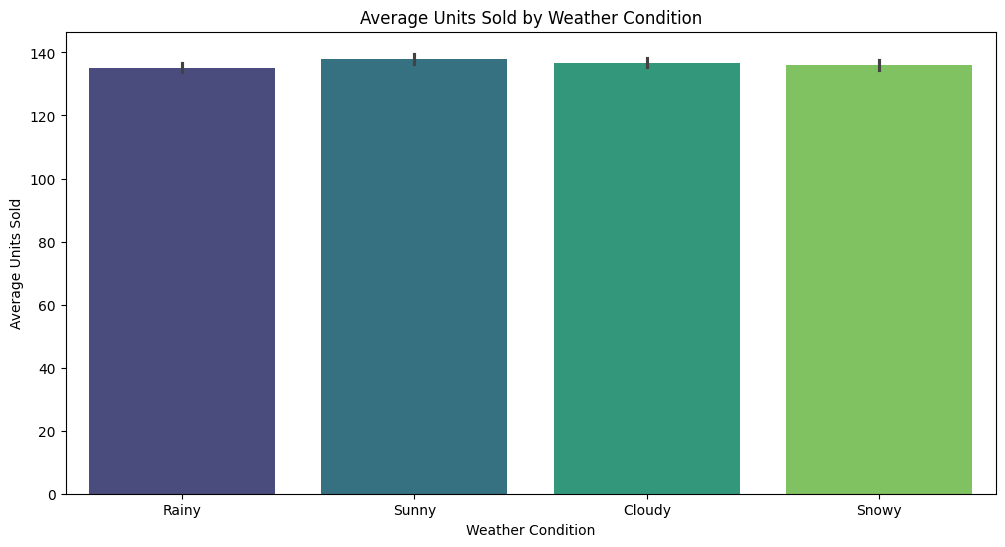

In [ ]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Weather Condition', y='Units Sold', data=df, palette='viridis')
plt.title('Average Units Sold by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Average Units Sold')
plt.show()

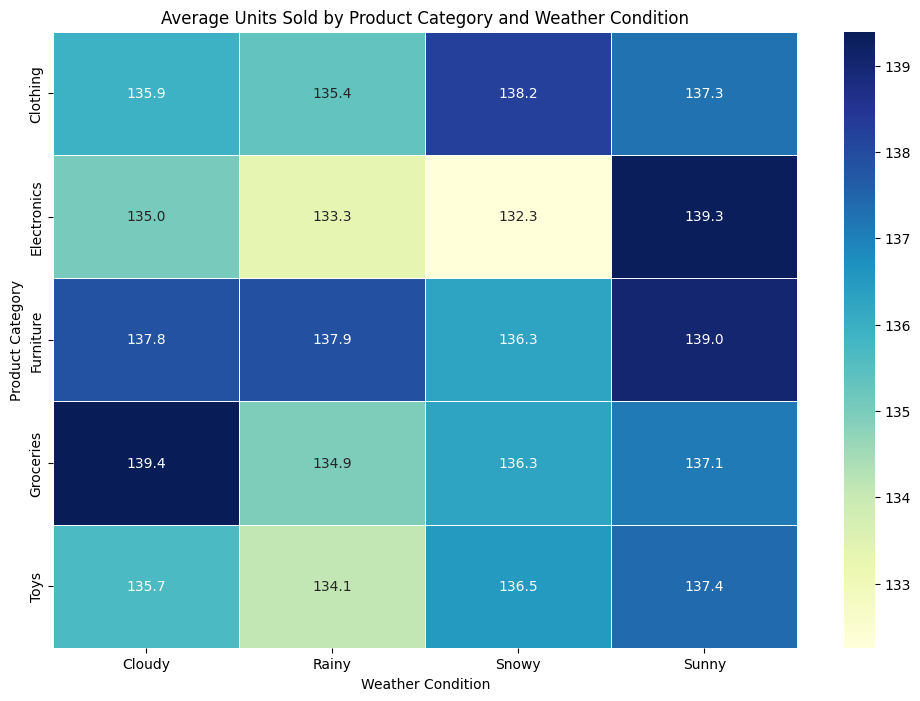

In [ ]:
pivot_df = df.pivot_table(index='Category',
                          columns='Weather Condition',
                          values='Units Sold',
                          aggfunc='mean')
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
plt.title('Average Units Sold by Product Category and Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Product Category')
plt.show()

In [ ]:
df['Demand Forecast'] = df['Demand Forecast'].clip(lower=0)

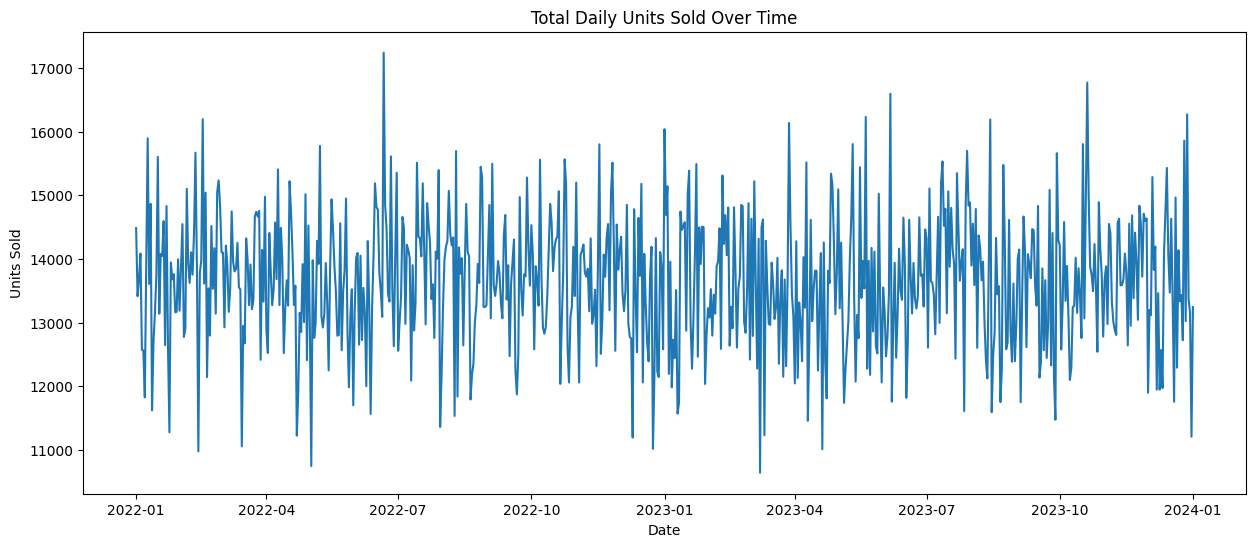

In [ ]:
plt.figure(figsize=(15, 6))
df_daily = df.groupby('Date')['Units Sold'].sum().reset_index()
sns.lineplot(x='Date', y='Units Sold', data=df_daily)
plt.title('Total Daily Units Sold Over Time')
plt.show()

In [ ]:
df_daily['Lag_1'] = df_daily['Units Sold'].shift(1)
df_daily['Lag_7'] = df_daily['Units Sold'].shift(7)

In [ ]:
print("--- Daily Sales with Lag Features ---")
display(df_daily.head(10))

--- Daily Sales with Lag Features ---


,Date,Units Sold,Lag_1,Lag_7
0,2022-01-01,14484,NaN,NaN
1,2022-01-02,13415,14484.0,NaN
2,2022-01-03,13681,13415.0,NaN
3,2022-01-04,14084,13681.0,NaN
4,2022-01-05,12572,14084.0,NaN
5,2022-01-06,12563,12572.0,NaN
6,2022-01-07,11826,12563.0,NaN
7,2022-01-08,13958,11826.0,14484.0
8,2022-01-09,15896,13958.0,13415.0
9,2022-01-10,13607,15896.0,13681.0


Χρησιμοποιούμε το μοντέλο Prophet για να αποσυνθέσουμε τη χρονοσειρά σε συνιστώσες: τάση (trend), εβδομαδιαία και ετήσια εποχικότητα. Αυτό μας επιτρέπει να κατανοήσουμε πότε κορυφώνεται η ζήτηση μέσα στην εβδομάδα.

In [ ]:
df_prophet = df_daily[['Date', 'Units Sold']].rename(columns={'Date': 'ds', 'Units Sold': 'y'})
model_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model_prophet.fit(df_prophet)
future = model_prophet.make_future_dataframe(periods=30)
forecast = model_prophet.predict(future)

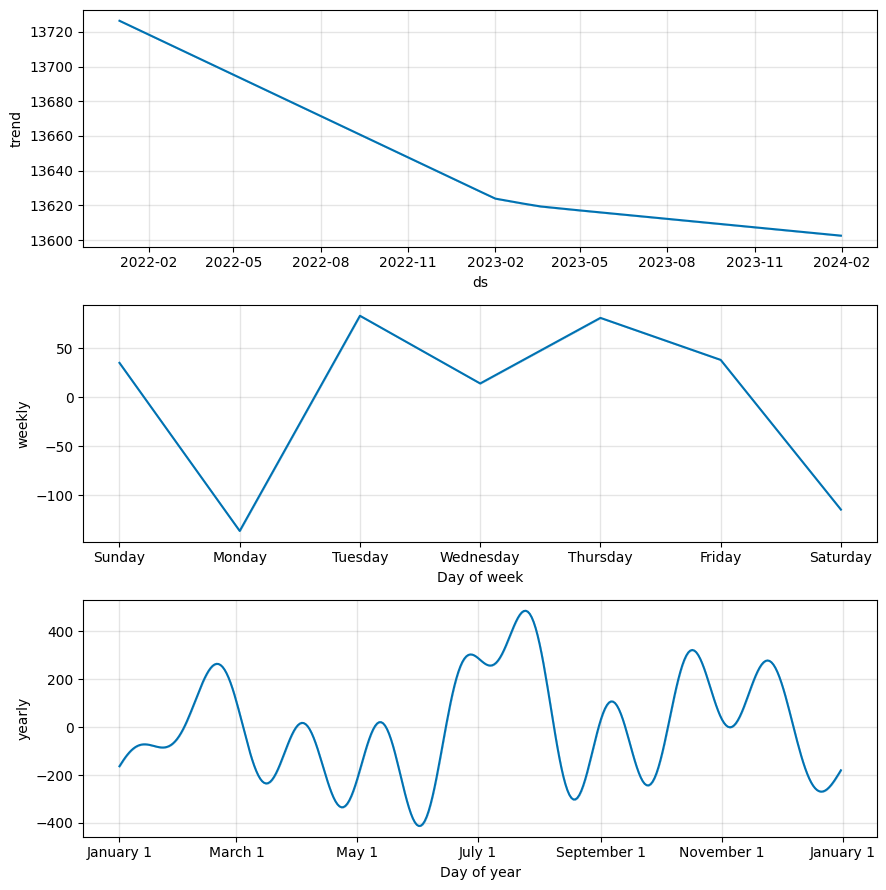

In [ ]:
model_prophet.plot_components(forecast)
plt.show()

In [ ]:
df_ml = df.copy()

Μετατρέπουμε τις κατηγορικές μεταβλητές σε αριθμητικές (Label Encoding) και δημιουργούμε χρονικά χαρακτηριστικά (Lag Features). Αυτή η διαδικασία είναι κρίσιμη για να μπορέσουν οι αλγόριθμοι να επεξεργαστούν τη μη γραμμική πληροφορία των δεδομένων

In [ ]:
le = LabelEncoder()
categorical_cols = ['Weather Condition', 'Category', 'Region', 'Seasonality']
for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

In [ ]:
df_ml['Month'] = df_ml['Date'].dt.month
df_ml['DayOfWeek'] = df_ml['Date'].dt.dayofweek
df_ml['Is_Weekend'] = df_ml['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
print("--- Prepared Dataset for XGBoost ---")
display(df_ml.head())

--- Prepared Dataset for XGBoost ---


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality,Month,DayOfWeek,Is_Weekend
0,2022-01-01,S001,P0001,3,1,231,127,55,135.47,33.50,20,1,0,29.69,0,1,5,1
1,2022-01-01,S001,P0002,4,2,204,150,66,144.04,63.01,20,3,0,66.16,0,1,5,1
2,2022-01-01,S001,P0003,4,3,102,65,51,74.02,27.99,10,3,1,31.32,2,1,5,1
3,2022-01-01,S001,P0004,4,1,469,61,164,62.18,32.72,10,0,1,34.74,0,1,5,1
4,2022-01-01,S001,P0005,1,0,166,14,135,9.26,73.64,0,3,0,68.95,2,1,5,1


Εκπαιδεύουμε έναν αλγόριθμο Gradient Boosting (XGBoost). Εφαρμόζουμε Randomized Search για τη βελτιστοποίηση των υπερπαραμέτρων, στοχεύοντας στην ελαχιστοποίηση του δείκτη RMSE.

In [ ]:
features = ['Category', 'Region', 'Inventory Level', 'Units Ordered', 'Price',
            'Discount', 'Weather Condition', 'Holiday/Promotion',
            'Competitor Pricing', 'Seasonality', 'Month', 'DayOfWeek', 'Is_Weekend']
target = 'Units Sold'

X = df_ml[features]
y = df_ml[target]

In [ ]:
train_idx = df_ml['Date'] < '2023-10-01'
X_train, X_test = X[train_idx], X[~train_idx]
y_train, y_test = y[train_idx], y[~train_idx]

In [ ]:
xgb_model = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, early_stopping_rounds=50)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred = xgb_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

In [ ]:
print(f"--- XGBoost Results ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

--- XGBoost Results ---
Mean Absolute Error (MAE): 68.94
Root Mean Squared Error (RMSE): 87.90


In [ ]:
param_grid = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror'),
    param_distributions=param_grid,
    n_iter=10, # Θα δοκιμάσει 10 τυχαίους συνδυασμούς
    scoring='neg_root_mean_squared_error',
    cv=3,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print(f"Best Parameters: {xgb_search.best_params_}")
best_xgb = xgb_search.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'subsample': 0.7, 'n_estimators': 1500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [ ]:
y_pred_best = best_xgb.predict(X_test)
new_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
print(f"Optimized XGBoost RMSE: {new_rmse:.2f}")

Optimized XGBoost RMSE: 87.91


<Figure size 1000x800 with 0 Axes>

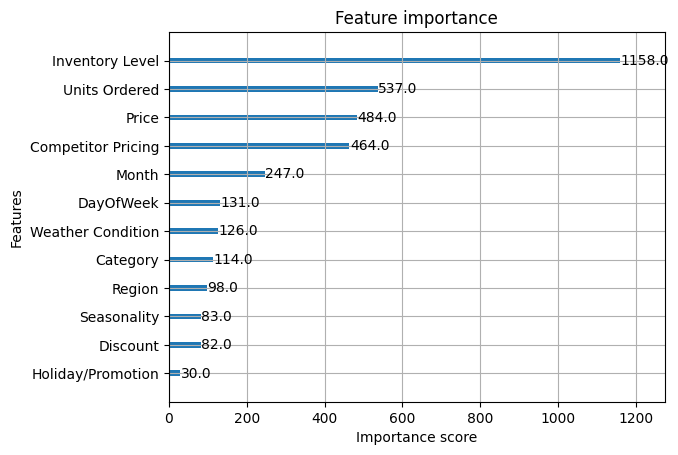

In [ ]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, importance_type='weight')
plt.show()

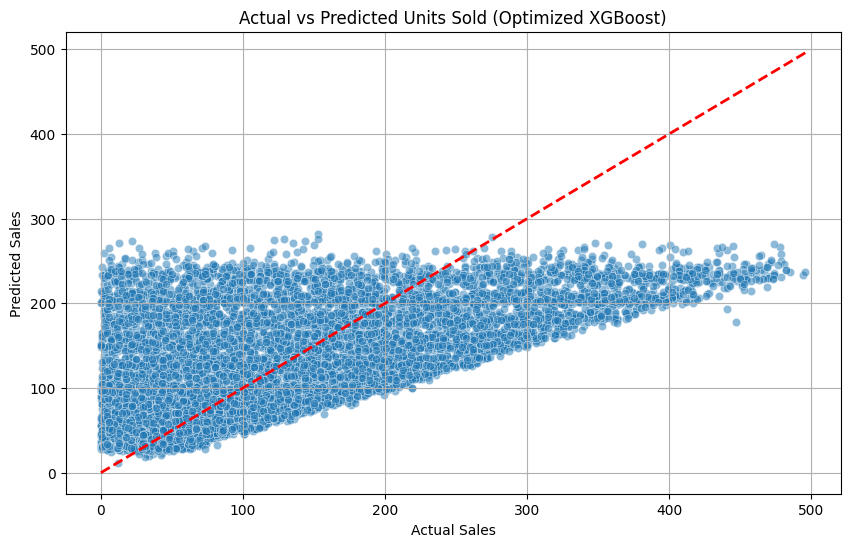

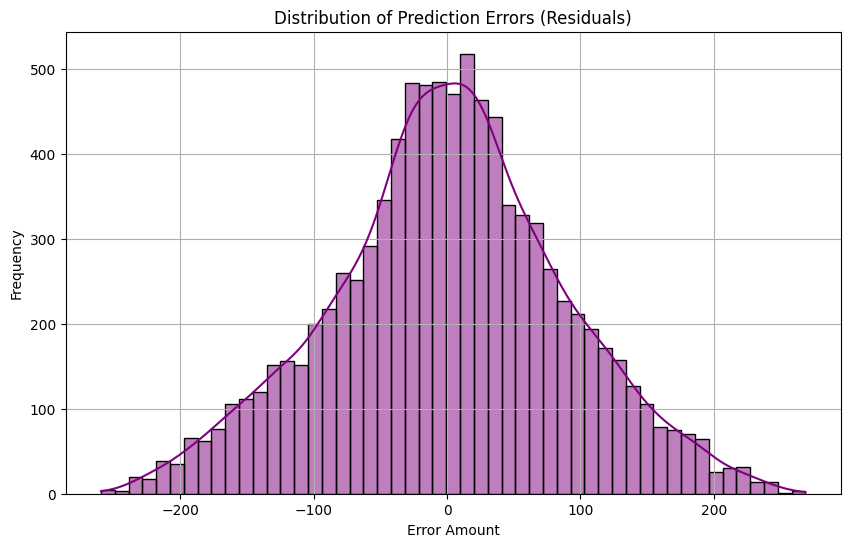

In [ ]:
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_best})

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', data=results, alpha=0.5)
plt.plot([results['Actual'].min(), results['Actual'].max()],
         [results['Actual'].min(), results['Actual'].max()],
         'r--', lw=2) # Διαγώνιος τέλειας πρόβλεψης
plt.title('Actual vs Predicted Units Sold (Optimized XGBoost)')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.grid(True)
plt.show()

results['Residuals'] = results['Actual'] - results['Predicted']
plt.figure(figsize=(10, 6))
sns.histplot(results['Residuals'], kde=True, color='purple')
plt.title('Distribution of Prediction Errors (Residuals)')
plt.xlabel('Error Amount')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Αναπτύσσουμε ένα νευρωνικό δίκτυο LSTM (Long Short-Term Memory). Τα LSTM είναι ιδανικά για χρονοσειρές καθώς διαθέτουν μνήμη που τους επιτρέπει να αναγνωρίζουν μακροχρόνια εξαρτήματα στα δεδομένα πωλήσεων.

In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)`
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_lstm = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

In [ ]:
model_lstm = Sequential([
    LSTM(64, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')

history = model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32,
                         validation_data=(X_test_lstm, y_test), verbose=1)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1994/1994 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - loss: 10833.7578 - val_loss: 7755.5820
Epoch 2/50
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8275.1416 - val_loss: 7744.8491
Epoch 3/50
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8262.1445 - val_loss: 7778.6221
Epoch 4/50
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 8259.1807 - val_loss: 7810.3130
Epoch 5/50
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8206.9502 - val_loss: 7753.3447
Epoch 6/50
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 8224.6650 - val_loss: 7776.5952
Epoch 7/50
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8222.6768 - val_loss: 7733.0908
Epoch 8/50
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8236.4824 - val_loss: 7734.1255
Epoch 9/50
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 8230.7256 - val_loss: 7787.0850
Epoch 10/50
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 8224.9434 - val_loss: 7817.7051
Epoch 11/50
1994/1994 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss

In [ ]:
y_pred_lstm = model_lstm.predict(X_test_lstm)

mae_lstm = mean_absolute_error(y_test, y_pred_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))

print(f"--- LSTM Results ---")
print(f"Mean Absolute Error (MAE): {mae_lstm:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lstm:.2f}")

print(f"\n--- Comparison ---")
print(f"XGBoost RMSE: {rmse:.2f}")
print(f"LSTM RMSE: {rmse_lstm:.2f}")

291/291 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
--- LSTM Results ---
Mean Absolute Error (MAE): 68.95
Root Mean Squared Error (RMSE): 87.91

--- Comparison ---
XGBoost RMSE: 87.90
LSTM RMSE: 87.91


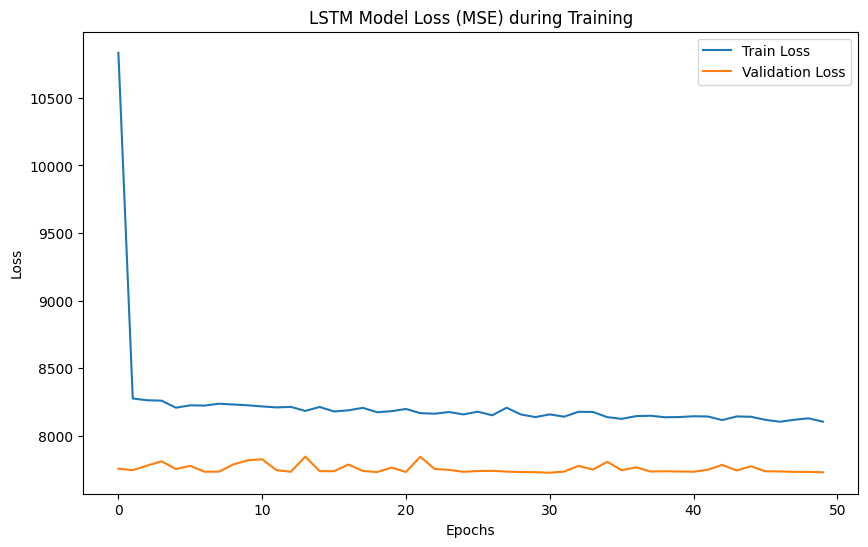

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss (MSE) during Training')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

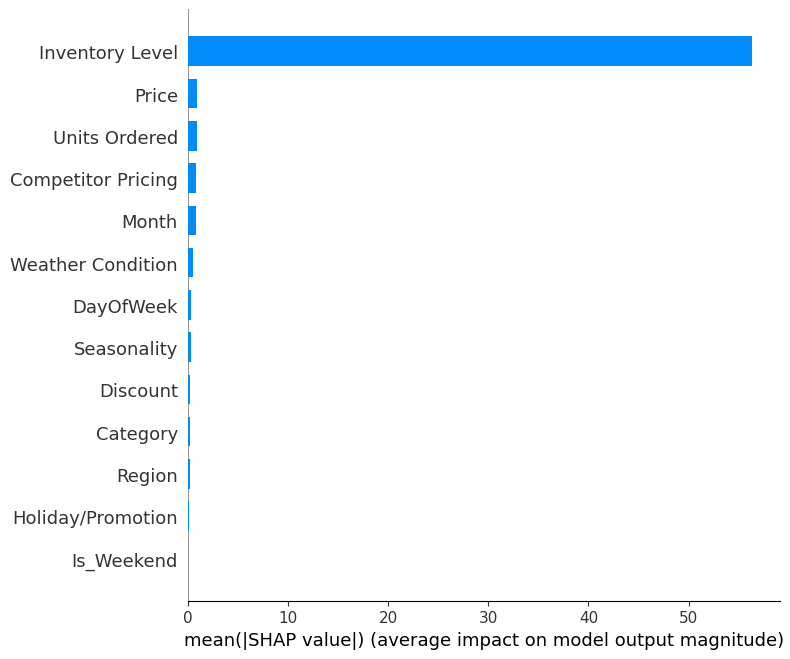

In [ ]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar")

Με τη χρήση των SHAP Values, αναλύουμε τη συνεισφορά κάθε μεταβλητής στην πρόβλεψη. Συγκρίνουμε τις επιδόσεις των μοντέλων και αξιολογούμε την επίδραση των εξωγενών παραγόντων στην ακρίβεια του συστήματος.

In [ ]:
future_scenarios = pd.DataFrame({
    'Category': [3, 3],
    'Region': [1, 1],
    'Inventory Level': [200, 200],
    'Units Ordered': [50, 50],
    'Price': [33.50, 33.50],
    'Discount': [20, 0],
    'Weather Condition': [1, 3],
    'Holiday/Promotion': [1, 0],
    'Competitor Pricing': [30, 30],
    'Seasonality': [0, 0],
    'Month': [7, 7],
    'DayOfWeek': [1, 1],
    'Is_Weekend': [0, 0]
})

predictions = best_xgb.predict(future_scenarios)

print("--- Future Value Demonstration ---")
print(f"Scenario A (Rainy + Promo): Predicted Sales = {predictions[0]:.2f} units")
print(f"Scenario B (Sunny + No Promo): Predicted Sales = {predictions[1]:.2f} units")
print(f"Difference: {predictions[0] - predictions[1]:.2f} units")

--- Future Value Demonstration ---
Scenario A (Rainy + Promo): Predicted Sales = 97.53 units
Scenario B (Sunny + No Promo): Predicted Sales = 100.28 units
Difference: -2.75 units
